# Applied Logistic Regression to Predict Employee Attrition Risk

In [89]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Understanding the Data and Data Cleaning

In [90]:
df = pd.read_csv("dataset_03_employee_attrition.csv")
df.head()

,age,monthly_income,years_at_company,job_satisfaction,overtime_hours,promotion_years,target
0,18,554.86,2.69,1,8.30,1.22,1
1,60,104.33,5.99,4,1.00,7.71,1
2,36,205.49,0.82,2,7.03,2.80,0
3,25,372.61,0.00,3,9.18,0.00,1
4,43,228.28,8.66,7,14.67,5.11,0


In [91]:
low_satisfaction_pct = (df['job_satisfaction'] <= 4).mean() * 100
print(f"Percentage with job satisfaction <= 4: {low_satisfaction_pct:.1f}%")

print("\n Job satisfaction distribution:")
print(df['job_satisfaction'].value_counts().sort_index())

Percentage with job satisfaction <= 4: 81.9%

 Job satisfaction distribution:
job_satisfaction
0      44
1     160
2     214
3     224
4     177
5      86
6      52
7      32
8       9
10      2
Name: count, dtype: int64


In [92]:
df.describe()

,age,monthly_income,years_at_company,job_satisfaction,overtime_hours,promotion_years,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,41.234000,194.321590,5.251560,3.026000,10.525500,4.945410,0.50000
std,13.809633,177.698433,3.595384,1.753967,7.072481,3.571468,0.50025
min,18.000000,17.980000,0.000000,0.000000,1.000000,0.000000,0.00000
25%,29.000000,94.537500,2.507500,2.000000,4.847500,2.147500,0.00000
50%,41.000000,146.130000,5.070000,3.000000,9.500000,4.650000,0.50000
75%,53.000000,232.142500,7.715000,4.000000,15.302500,7.372500,1.00000
max,65.000000,2161.230000,20.690000,10.000000,31.960000,16.500000,1.00000


#### We need to see the outliers

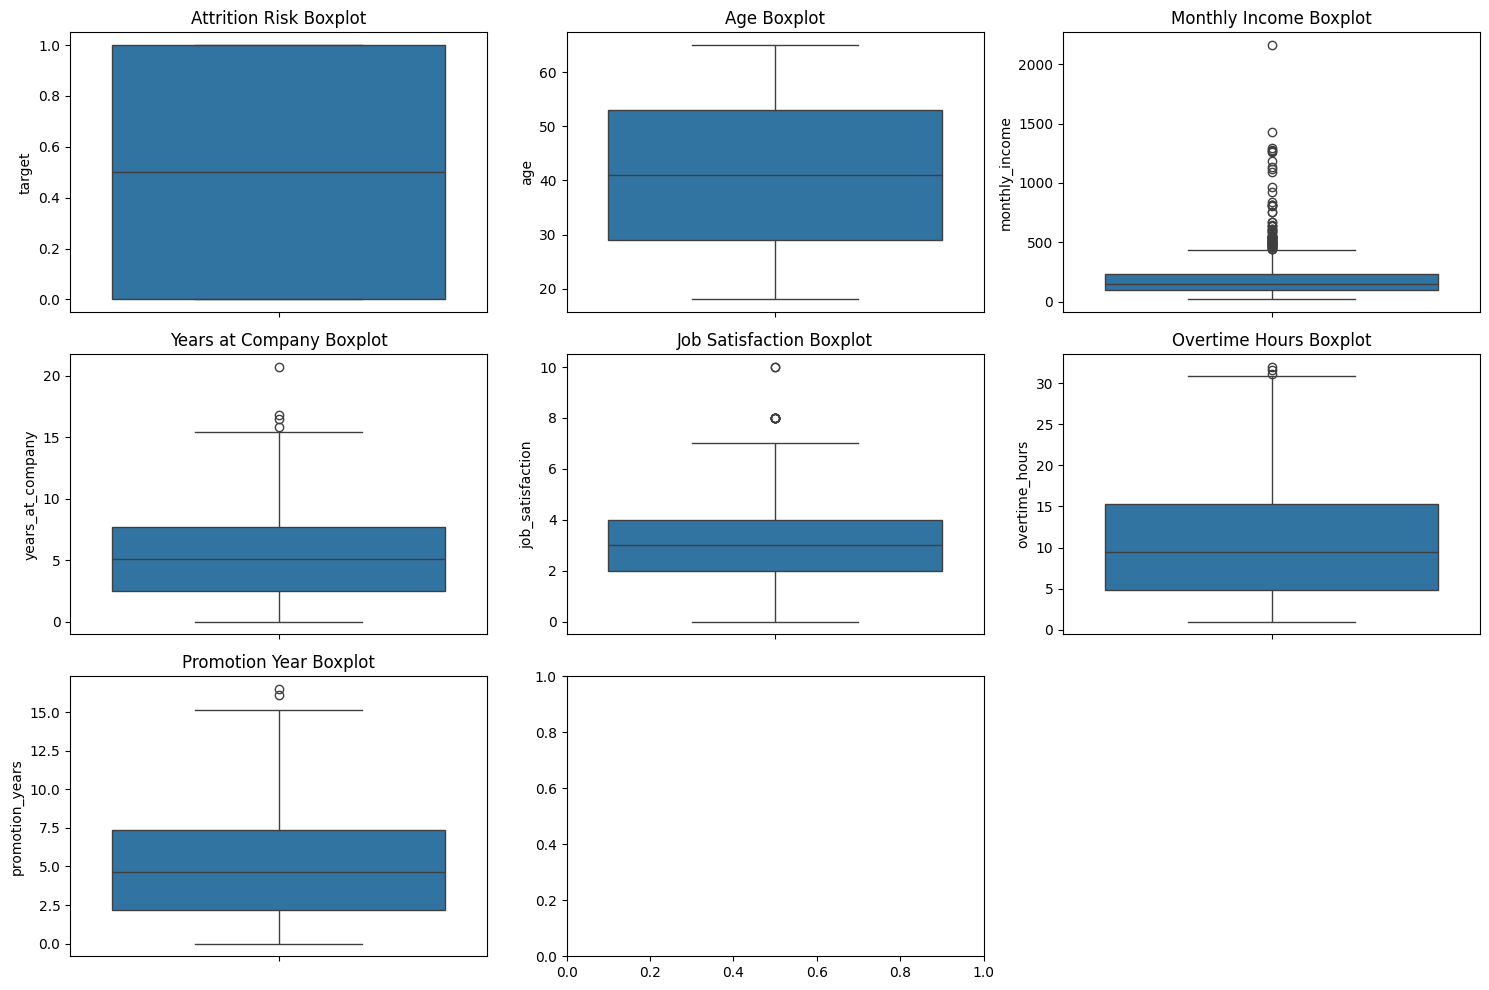

In [93]:
fig, axes = plt.subplots(3,3, figsize=(15,10))
axes = axes.flatten()

columns = ['target', 'age', 'monthly_income', 'years_at_company', 'job_satisfaction', 'overtime_hours', 'promotion_years']
titles = ['Attrition Risk', 'Age', 'Monthly Income', 'Years at Company', 'Job Satisfaction', 'Overtime Hours', 'Promotion Year']

for ax, col, title in zip(axes, columns, titles):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'{title} Boxplot')

axes[-1].set_visible(False)
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

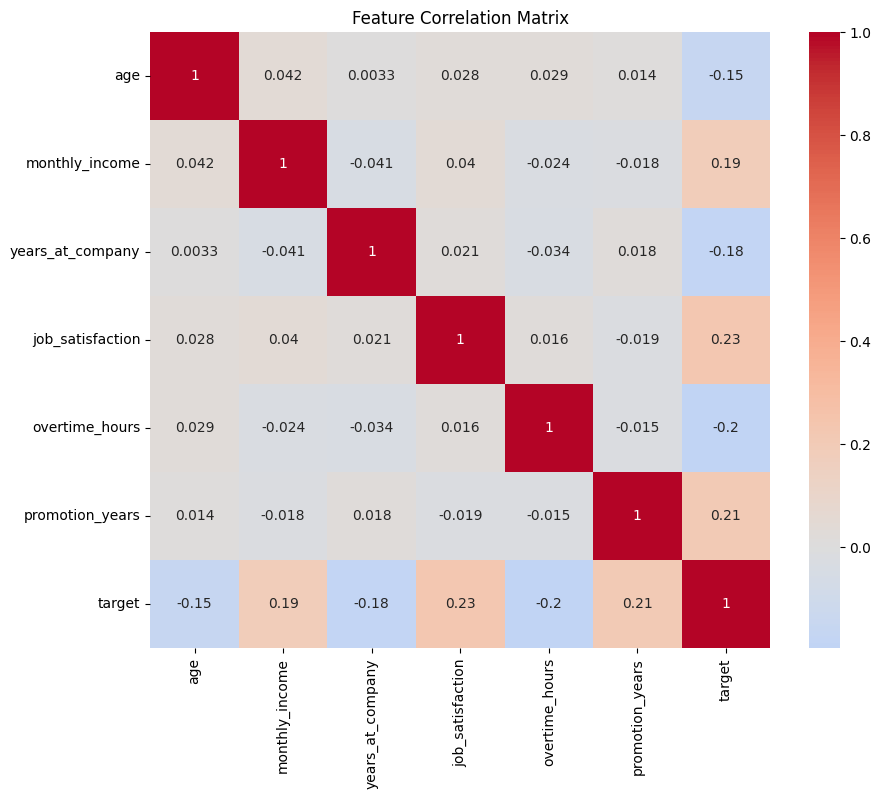

In [94]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm',center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1000 non-null   int64  
 1   monthly_income    1000 non-null   float64
 2   years_at_company  1000 non-null   float64
 3   job_satisfaction  1000 non-null   int64  
 4   overtime_hours    1000 non-null   float64
 5   promotion_years   1000 non-null   float64
 6   target            1000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 54.8 KB


In [96]:
df.isnull().sum()   

age                 0
monthly_income      0
years_at_company    0
job_satisfaction    0
overtime_hours      0
promotion_years     0
target              0
dtype: int64

In [97]:
df["target"].value_counts(normalize=True) * 100

target
1    50.0
0    50.0
Name: proportion, dtype: float64

In [98]:
d = df.duplicated().sum()
print(d)

0


In [99]:
invalid_age = df[(df['age'] < 0) | (df['age'] > 120)] 
print("Invalid age: ", len(invalid_age))


invalid_monthly_income = df[(df['monthly_income'] <= 0)]
invalid_years_at_company = df[(df['years_at_company'] <= 0)]
print("Invalid monthly income: ", len(invalid_age))
print("Invalid years at company: ", len(invalid_age))

invalid_columns = ['job_satisfaction', 'overtime_hours', 'promotion_years']

for col in invalid_columns:
    invalid_count = (df[col] < 0).sum()
    if invalid_count > 0:
        print(f"Invalid col: {col} : {invalid_count}")
    else:
        print(f"{col} No negative values")

Invalid age:  0
Invalid monthly income:  0
Invalid years at company:  0
job_satisfaction No negative values
overtime_hours No negative values
promotion_years No negative values


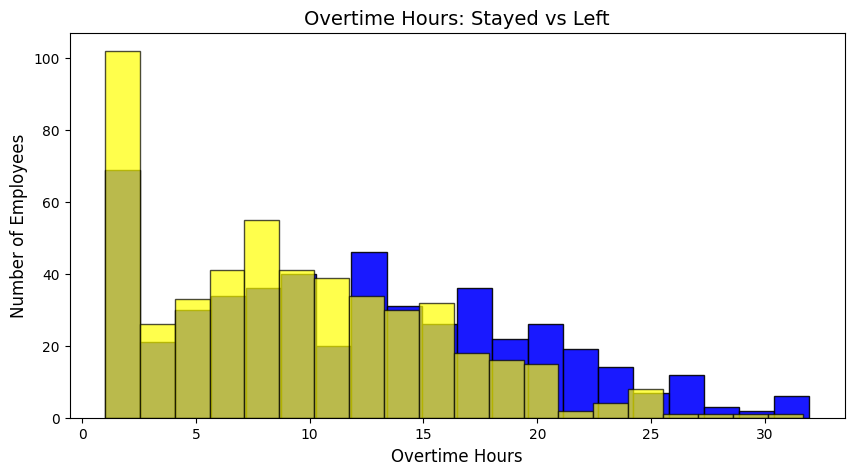

In [100]:
plt.figure(figsize=(10,5))

plt.hist(df[df['target'] == 0]['overtime_hours'], bins=20, alpha=0.9, label='Stayed (0)', edgecolor='black', color='blue')

plt.hist(df[df['target'] == 1]['overtime_hours'], bins=20, alpha=0.7, label='Left (1)', edgecolor='black', color='yellow')

plt.title("Overtime Hours: Stayed vs Left", fontsize=14)
plt.xlabel("Overtime Hours", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.show()

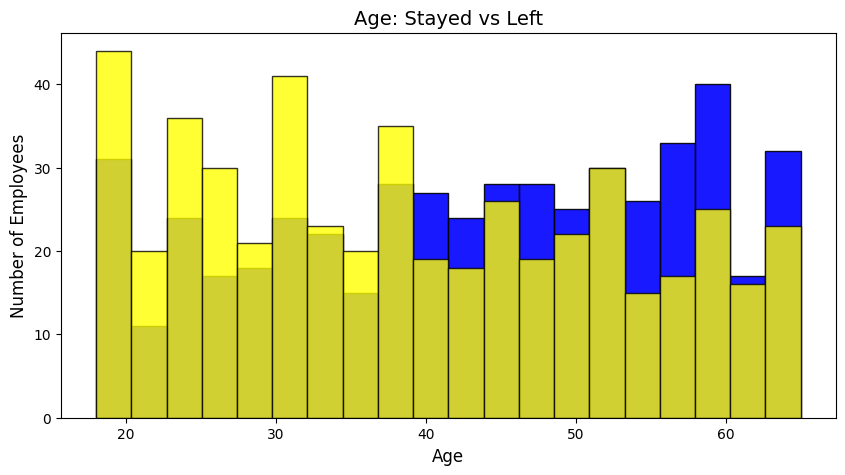

In [101]:
plt.figure(figsize=(10,5))

plt.hist(df[df['target'] == 0]['age'], bins=20, alpha=0.9, label='Stayed (0)', edgecolor='black', color='blue')
plt.hist(df[df['target'] == 1]['age'], bins=20, alpha=0.8, label='Left (1)', edgecolor='black', color='yellow')


plt.title("Age: Stayed vs Left", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.show()

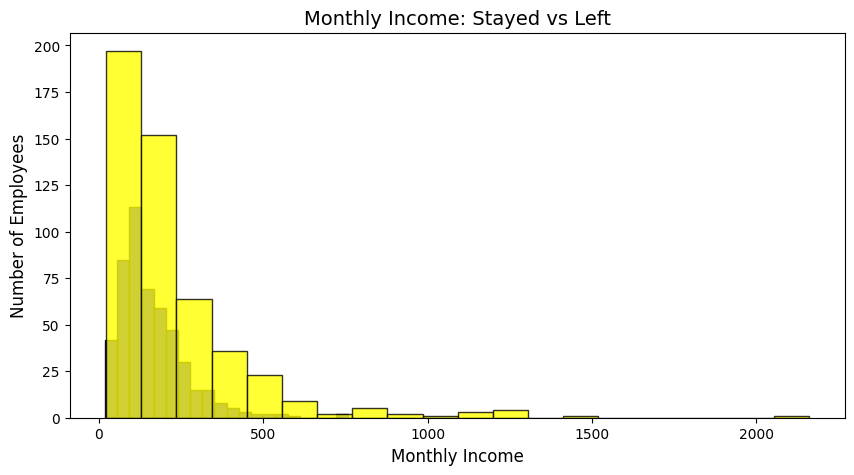

In [102]:
plt.figure(figsize=(10,5))

plt.hist(df[df['target'] == 0]['monthly_income'], bins=20, alpha=0.9, edgecolor='black', color='blue')
plt.hist(df[df['target'] == 1]['monthly_income'], bins=20, alpha=0.8, edgecolor='black', color='yellow')

plt.title("Monthly Income: Stayed vs Left", fontsize=14)
plt.xlabel("Monthly Income", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.show()

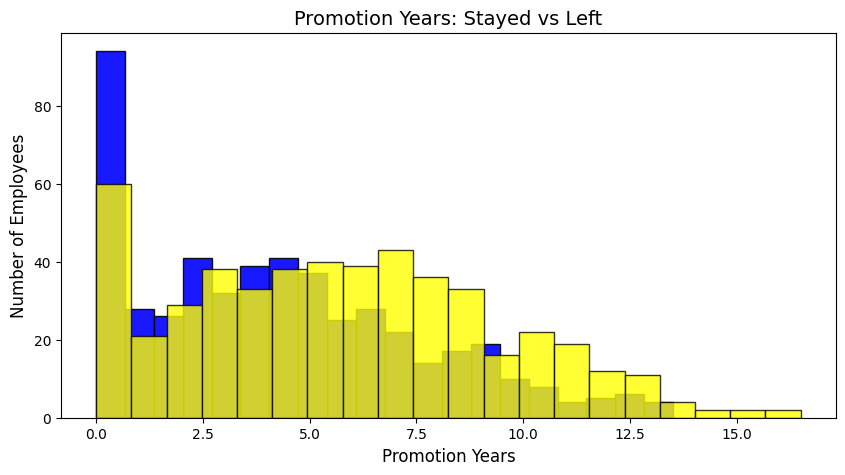

In [103]:
plt.figure(figsize=(10,5))

plt.hist(df[df['target'] == 0]['promotion_years'], bins=20, alpha=0.9, edgecolor='black', color='blue')
plt.hist(df[df['target'] == 1]['promotion_years'], bins=20, alpha=0.8, edgecolor='black', color='yellow')

plt.title("Promotion Years: Stayed vs Left", fontsize=14)
plt.xlabel("Promotion Years", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.show()

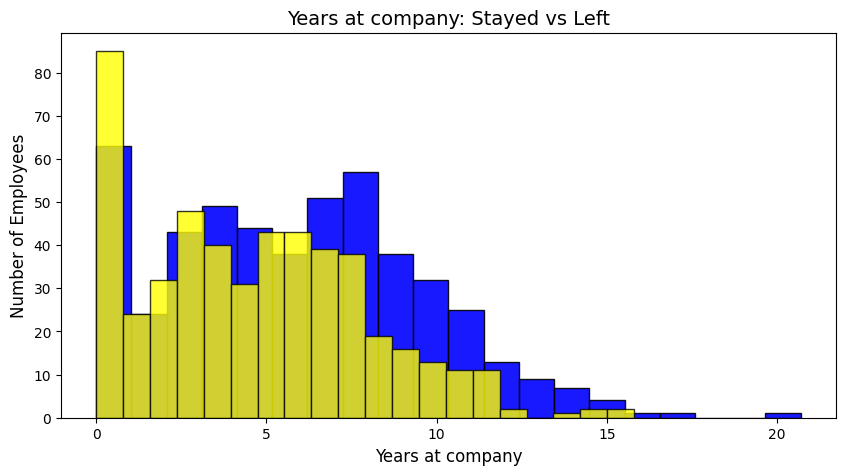

In [104]:
plt.figure(figsize=(10,5))

plt.hist(df[df['target'] == 0]['years_at_company'], bins=20, alpha=0.9, edgecolor='black', color='blue')
plt.hist(df[df['target'] == 1]['years_at_company'], bins=20, alpha=0.8, edgecolor='black', color='yellow')

plt.title("Years at company: Stayed vs Left", fontsize=14)
plt.xlabel("Years at company", fontsize=12)
plt.ylabel("Number of Employees", fontsize=12)
plt.show()

### Data Splitting

In [105]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, Y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

#### We need to scale the data

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training using Logistic Regression Algorithm

In [107]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, Y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Evaluate the Performance of the Model

In [108]:
y_pred = model.predict(X_test_scaled)
print(y_pred[:10])

[1 0 0 0 0 1 1 0 0 1]


In [109]:
probability_score = model.predict_proba(X_test_scaled)
print(probability_score[:10])

[[0.48620935 0.51379065]
 [0.65054703 0.34945297]
 [0.53317859 0.46682141]
 [0.73053566 0.26946434]
 [0.74011131 0.25988869]
 [0.34519311 0.65480689]
 [0.32907374 0.67092626]
 [0.63548737 0.36451263]
 [0.69480322 0.30519678]
 [0.31954879 0.68045121]]


In [110]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.665


In [111]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("Classification Report")
print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Leave (1)']))

ps = precision_score(y_test, y_pred)
rs = recall_score(y_test, y_pred)
f1s = f1_score(y_test, y_pred)

print(f"Overall Precision: {ps:.4f}")
print(f"Overall Recall: {rs:.4f}")
print(f"Overall F1-Score: {f1s:.4f}")

Classification Report
              precision    recall  f1-score   support

    Stay (0)       0.67      0.66      0.66       100
   Leave (1)       0.66      0.67      0.67       100

    accuracy                           0.67       200
   macro avg       0.67      0.67      0.66       200
weighted avg       0.67      0.67      0.66       200

Overall Precision: 0.6634
Overall Recall: 0.6700
Overall F1-Score: 0.6667


In [112]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[66 34]
 [33 67]]


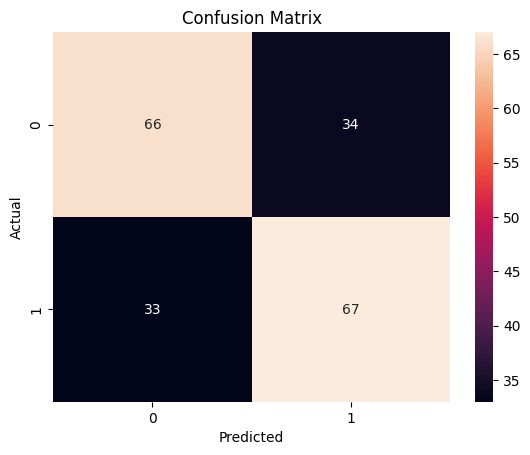

In [113]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### ROC & AUC

to see model quality and visualize performance

In [114]:
from sklearn.metrics import roc_auc_score, roc_curve

y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
ra_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {ra_score:.4f}")

ROC AUC Score: 0.7391


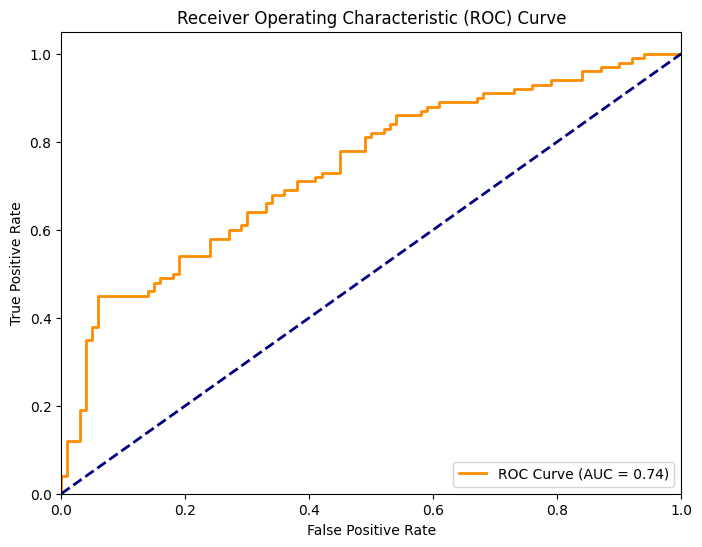

In [115]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {ra_score:.2f})")
plt.plot([0,1],[0,1], color="navy", lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

### Feature Coefficient Interpretation

In [116]:
coefficient_series = pd.Series(model.coef_[0], index=X.columns).sort_values()
print(f'Feature Coefficients: {coefficient_series}')

Feature Coefficients: overtime_hours     -0.619121
years_at_company   -0.446574
age                -0.438686
monthly_income      0.583814
promotion_years     0.613644
job_satisfaction    0.655048
dtype: float64


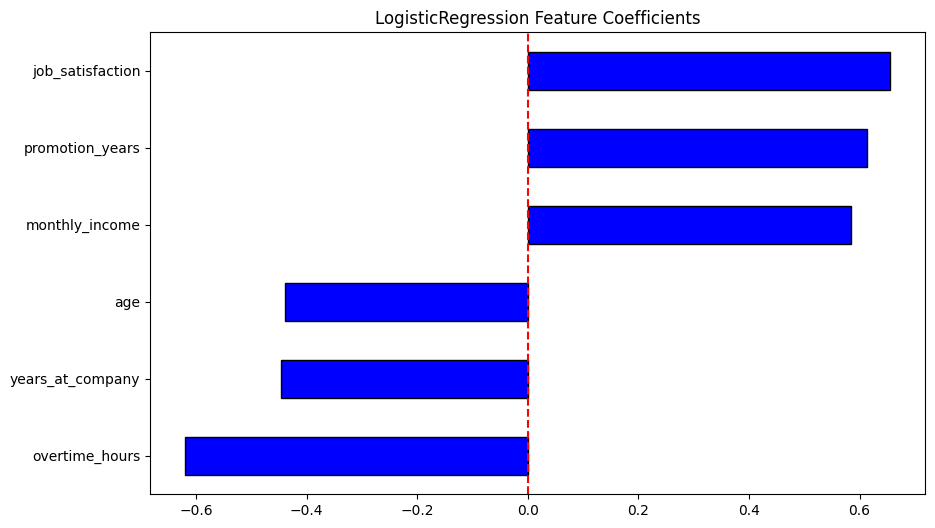

In [117]:
coefficient_series.plot(kind='barh', figsize=(10,6), color='blue', edgecolor='black')

plt.axvline(x=0, color='red', linestyle='--')
plt.title('LogisticRegression Feature Coefficients')
plt.show()

### Error Analysis

In [118]:
tn, fp, fn, tp = cm.ravel()

print(f'False Positives: {fp} (predicted leave but stayed)')
print(f'False Negative: {fn} (predicted stay but left)')
print(f'Total Errors: {fp + fn} out of {len(y_test)} ({(fp+fn)/len(y_test) *100:.1f})% error rate')

False Positives: 34 (predicted leave but stayed)
False Negative: 33 (predicted stay but left)
Total Errors: 67 out of 200 (33.5)% error rate
